In [1]:
NUM_STEPS = 10000000
MAX_THREADS = 16

In [4]:
%%writefile pi.cpp

#include <iostream>
#include <omp.h>
#include <cstdlib>

using namespace std;

int main(int argc, char* argv[]){
  int threads = atoi(argv[1]);
  long num_steps = atol(argv[2]);

  omp_set_num_threads(threads);

  double step = 1.0 / (double)num_steps;
  double sum = 0.0;

  double start = omp_get_wtime();

  #pragma omp parallel for reduction(+:sum)
  for(long i=0; i<num_steps; i++){
    double x = (i+0.5) * step;
    sum+= 4.0 / (1.0 + x*x);
  }

  double pi = step*sum;
  double end = omp_get_wtime();

  cout << pi << " " << (end - start);
}

Overwriting pi.cpp


3.14159


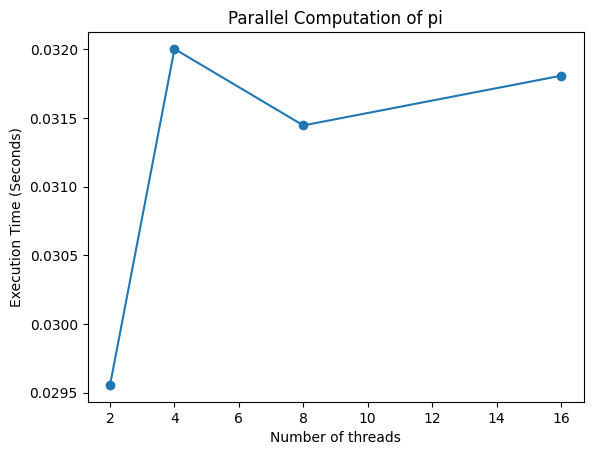

In [6]:
import subprocess
import matplotlib.pyplot as plt

!g++ -fopenmp pi.cpp -o pi

threads = []
times = []

t=2

while t<=MAX_THREADS:
  output = subprocess.check_output(
      ["./pi", str(t), str(NUM_STEPS)]
  ).decode().strip()

  pi_val, time_taken = output.split()
  threads.append(t)
  times.append(float(time_taken))
  t*=2

print(pi_val)

plt.figure()
plt.plot(threads, times, marker='o')
plt.xlabel("Number of threads")
plt.ylabel("Execution Time (Seconds)")
plt.title("Parallel Computation of pi")
plt.show()